# Motion sensitivity in balanced SSFP

Balanced SSFP returns every gradient axis to zero net area over each RF-to-RF interval. For a
**stationary** spin that is the end of the story: the gradients it saw integrate to nothing, and
it arrives at the echo with no gradient-induced phase.

A spin that is *moving* sees something else. If it travels at constant velocity $v$ along an
axis, its position is $x(t) = x_0 + v\,t$, and the phase it accumulates from that axis'
gradient $G(t)$ between the RF effective centre and the echo is

$$\phi = 2\pi \int G(t)\,x(t)\,\mathrm{d}t = 2\pi\left(x_0 M_0 + v\,M_1\right),$$

with the gradient moments taken about the RF effective centre:

$$M_0 = \int G(t)\,\mathrm{d}t, \qquad M_1 = \int G(t)\,t\,\mathrm{d}t .$$

So **$M_0 = 0$ removes the position term and leaves the velocity term**. The moving spin arrives
with a phase $2\pi v M_1$ that the stationary spin beside it does not have, and across a voxel
containing a spread of velocities that phase spread costs signal. In a vessel it displaces the
signal in the phase-encode direction; at a vessel edge it produces the dark rim familiar from
flow artefacts.

**Flow compensation** — also called gradient moment nulling — asks for $M_1 = 0$ at the echo as
well as $M_0$. It is a strictly stronger requirement than balance, it is a different requirement
from balance, and it costs echo time.

This notebook measures both on the shipped kernel, builds the compensated variant, and simulates
a moving spin to see the difference rather than only to report it.

```text
01_build.ipynb      the canonical balanced repetition and acquisition
02_simulate...      transients, preparation, and the steady state
03_flow_comp.ipynb  first moments, and the motion-robust variant
```

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import contextlib
import os as _os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 60
warnings.filterwarnings('ignore', message='To copy construct from a tensor')

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)

opts = pp.Opts(
    max_grad=24, grad_unit='mT/m', max_slew=120, slew_unit='T/m/s', B0=3.0,
    rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
)
FOV_MM, MATRIX, THICKNESS_MM = 250.0, (64, 64), 6.0
FLIP_DEG, BANDWIDTH_HZ_PX = 40.0, 700.0
NX, NY = MATRIX
CENTRE_LINE = NY // 2

PROTOCOL = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                flip_deg=FLIP_DEG, bandwidth_hz_px=BANDWIDTH_HZ_PX)

canonical = sc.modules.bSSFP2DTR(**PROTOCOL)
print(f'canonical   TE {canonical.te_s * 1e3:.3f} ms   TR {canonical.tr_s * 1e3:.3f} ms')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


canonical   TE 3.425 ms   TR 6.850 ms


## 1. The moments the canonical repetition actually has

Measured on the emitted waveform rather than inferred from how the lobes look: compile a short
train, find the RF effective centres, and integrate each axis between the instants that matter.

Two reference times are worth looking at:

```text
RF effective centre -> echo              what a moving spin carries into the signal
RF effective centre -> next RF centre    the balance interval, which is about M0 only
```

In [2]:
def rf_centres(seq):
    """Absolute time of every RF effective centre, seconds."""
    out, t = [], 0.0
    for i in range(1, len(seq.block_events) + 1):
        block = seq.get_block(i)
        if getattr(block, 'rf', None) is not None:
            out.append(t + float(block.rf.delay) + float(pp.calc_rf_center(block.rf)[0]))
        t += float(seq.block_durations[i])
    return np.array(out)


def moments(seq, start, end, origin, order):
    """``(Mx, My, Mz)`` of the given order over ``[start, end]``, about `origin`."""
    waveforms = seq.waveforms_and_times()[0]
    out = []
    for axis in range(3):
        t, g = waveforms[axis][0], waveforms[axis][1]
        if len(t) == 0:
            out.append(0.0)
            continue
        grid = np.unique(np.concatenate([t[(t > start) & (t < end)], [start, end]]))
        v = np.interp(grid, t, g, left=0.0, right=0.0)
        out.append(float(np.trapezoid(v * (grid - origin) ** order, grid)))
    return np.array(out)


def measure(kernel, lines):
    """Compile three repetitions and report the moments of the first."""
    scan = sc.LogicBlock()
    for index, line in enumerate(lines):
        scan.add(index * kernel.tr_s, kernel(line=line, phase_deg=180.0 * (index % 2)))
    seq = sc.compile(scan, opts)
    c = rf_centres(seq)
    return {
        'm0_echo': moments(seq, c[0], c[0] + kernel.te_s, c[0], 0),
        'm1_echo': moments(seq, c[0], c[0] + kernel.te_s, c[0], 1),
        'm0_rf2rf': moments(seq, c[0], c[1], c[0], 0),
        'm1_rf2rf': moments(seq, c[0], c[1], c[0], 1),
    }


m = measure(canonical, [CENTRE_LINE, CENTRE_LINE + 1, CENTRE_LINE + 2])
print(f'{"":26}{"x":>13}{"y":>13}{"z":>13}')
for key, label, unit in (('m0_echo', 'M0 at the echo', '1/m'),
                         ('m1_echo', 'M1 at the echo', 's/m'),
                         ('m0_rf2rf', 'M0 over RF-to-RF', '1/m'),
                         ('m1_rf2rf', 'M1 over RF-to-RF', 's/m')):
    print(f'{label:26}' + ''.join(f'{v:13.3e}' for v in m[key]) + f'   {unit}')

                                      x            y            z
M0 at the echo               -2.842e-14    0.000e+00    3.837e-13   1/m
M1 at the echo                8.852e-02    0.000e+00   -5.516e-01   s/m
M0 over RF-to-RF             -2.913e-13    0.000e+00    2.274e-13   1/m
M1 over RF-to-RF              3.585e-03    0.000e+00   -1.762e-01   s/m


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/754078289.py:32: SeqCraftWarning: 3 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 135% at 4.260 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 135% at 11.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 135% at 17.960 ms)
  seq = sc.compile(scan, opts)


`M0` is zero on the readout and slice axes at the echo, carries the requested `ky` on the
phase-encode axis, and is zero on all three over the RF-to-RF interval — the balance condition
the build notebook establishes.

`M1` is **not** zero on any axis. That is not a defect in the repetition; it is what balanced
means. Nothing in the zero-area condition constrains where in time the area was played, and the
first moment is exactly that.

### `M1` across the phase-encode table

The phase-encode axis is the interesting one, because its `M1` is tied to the line being
acquired: a larger blip has a larger lever arm about the RF centre.

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/754078289.py:32: SeqCraftWarning: 9 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (grad 102% at 4.260 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 160% at 4.260 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 124% at 6.310 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (grad 102% at 11.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 159% at 11.110 ms) (+4 more sites)
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/754078289.py:32: SeqCraftWarning: 9 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (grad 101% at 4.260 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 155% at 4.260 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 117% at 6.310 ms), bSSFP2DTR, b

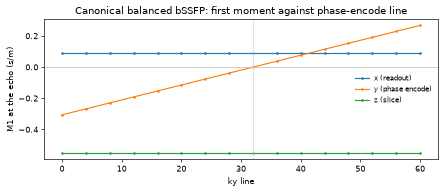

x and z are constant across the table: 0.00e+00 and 0.00e+00 s/m of spread
y runs from -0.306 to +0.268 s/m, and is zero at ky = 0 (line 32)


In [3]:
lines = np.arange(0, NY, 4)
m1_by_line = np.array([measure(canonical, [int(line), int(line) + 1, int(line) + 2])['m1_echo']
                       for line in lines])

fig, ax = plt.subplots(figsize=(7.5, 3.3))
for index, (label, style) in enumerate((('x (readout)', '-'), ('y (phase encode)', '-'),
                                        ('z (slice)', '-'))):
    ax.plot(lines, m1_by_line[:, index], style, lw=1.4, marker='.', ms=4, label=label)
ax.axhline(0.0, color='0.75', lw=0.9)
ax.axvline(CENTRE_LINE, color='0.85', lw=0.9)
ax.set_xlabel('ky line')
ax.set_ylabel('M1 at the echo (s/m)')
ax.set_title('Canonical balanced bSSFP: first moment against phase-encode line')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print(f'x and z are constant across the table: '
      f'{np.ptp(m1_by_line[:, 0]):.2e} and {np.ptp(m1_by_line[:, 2]):.2e} s/m of spread')
print(f'y runs from {m1_by_line[:, 1].min():+.3f} to {m1_by_line[:, 1].max():+.3f} s/m, '
      f'and is zero at ky = 0 (line {CENTRE_LINE})')

## 2. Asking for the first moment as well

`FlowCompensation` states the requirement — zero first moment at the echo on the named axes —
and the repetition designs a waveform that meets it alongside everything it already had to meet.

In [4]:
compensated = sc.modules.bSSFP2DTR(**PROTOCOL,
                                   flow_comp=sc.FlowCompensation(axis=('x', 'y', 'z')))

print(f'{"":14}{"TE (ms)":>10}{"TR (ms)":>10}{"TE/TR":>8}')
for name, kernel in (('canonical', canonical), ('compensated', compensated)):
    print(f'{name:14}{kernel.te_s * 1e3:10.3f}{kernel.tr_s * 1e3:10.3f}'
          f'{kernel.te_s / kernel.tr_s:8.3f}')
print(f'\ncost: TE +{(compensated.te_s - canonical.te_s) * 1e3:.3f} ms '
      f'({(compensated.te_s / canonical.te_s - 1) * 100:.0f}%), '
      f'TR +{(compensated.tr_s - canonical.tr_s) * 1e3:.3f} ms '
      f'({(compensated.tr_s / canonical.tr_s - 1) * 100:.0f}%)')

                 TE (ms)   TR (ms)   TE/TR
canonical          3.425     6.850   0.500
compensated        4.925     9.850   0.500

cost: TE +1.500 ms (44%), TR +3.000 ms (44%)


In [5]:
mc = measure(compensated, [CENTRE_LINE, CENTRE_LINE + 1, CENTRE_LINE + 2])

print(f'{"":30}{"x":>13}{"y":>13}{"z":>13}')
for key, label in (('m0_echo', 'M0 at the echo (1/m)'),
                   ('m1_echo', 'M1 at the echo (s/m)'),
                   ('m0_rf2rf', 'M0 over RF-to-RF (1/m)')):
    print(f'  canonical   {label:18}' + ''.join(f'{v:13.3e}' for v in m[key]))
    print(f'  compensated {label:18}' + ''.join(f'{v:13.3e}' for v in mc[key]))
    print()
for index, axis in enumerate('xyz'):
    before, after = abs(m['m1_echo'][index]), abs(mc['m1_echo'][index])
    if before < 1e-12:
        print(f'M1 on {axis}: already zero at this line (ky = 0); see the plot above for the '
              f'rest of the table')
    else:
        print(f'M1 on {axis}: {before:.3e} -> {after:.3e} s/m, a factor of {before / after:.0f}')

                                          x            y            z
  canonical   M0 at the echo (1/m)   -2.842e-14    0.000e+00    3.837e-13
  compensated M0 at the echo (1/m)    2.842e-13    0.000e+00   -6.821e-13

  canonical   M1 at the echo (s/m)    8.852e-02    0.000e+00   -5.516e-01
  compensated M1 at the echo (s/m)    4.783e-05    0.000e+00   -9.259e-05

  canonical   M0 over RF-to-RF (1/m)   -2.913e-13    0.000e+00    2.274e-13
  compensated M0 over RF-to-RF (1/m)    5.440e-15    0.000e+00   -1.705e-13

M1 on x: 8.852e-02 -> 4.783e-05 s/m, a factor of 1851
M1 on y: already zero at this line (ky = 0); see the plot above for the rest of the table
M1 on z: 5.516e-01 -> 9.259e-05 s/m, a factor of 5957


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/754078289.py:32: SeqCraftWarning: 8 same-axis gradient merges: bSSFP2DTR.joint (axis z) x3, bSSFP2DTR.CartesianLine (axis x) x3, bSSFP2DTR.joint (axis y) x2
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/754078289.py:32: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode, bSSFP2DTR.joint (grad 101% at 4.260 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode, bSSFP2DTR.joint (slew 129% at 4.260 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (grad 101% at 14.110 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (slew 129% at 14.110 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (grad 101% at 23.960 ms) (+1 more sites)
  seq = sc.compile(scan, opts)


Three things in that table, and they are separate claims:

```text
M1 at the echo        falls by three to four orders of magnitude on every axis.  The residual
                      is where the designer's realisation tolerance sits, not an intended value

M0 at the echo        unchanged: the readout and slice axes are still at k = 0 and the
                      phase-encode axis still carries the line that was asked for

M0 over RF-to-RF      unchanged, and still zero.  The compensated repetition is still balanced
```

The last one is the reason the two requirements compose. They live on different intervals: the
designer reshapes what plays between the RF centre and the echo and is handed the same **total**
area on each axis, so the sum over the whole repetition is the one the canonical waveform had.

### What the waveform had to become

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/808139658.py:6: SeqCraftWarning: 3 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 135% at 4.260 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 135% at 11.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 135% at 17.960 ms)
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/808139658.py:6: SeqCraftWarning: 8 same-axis gradient merges: bSSFP2DTR.joint (axis z) x3, bSSFP2DTR.CartesianLine (axis x) x3, bSSFP2DTR.joint (axis y) x2
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/808139658.py:6: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode, bSSFP2DTR.joint (grad 101% at 4.260 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode, bSSFP2

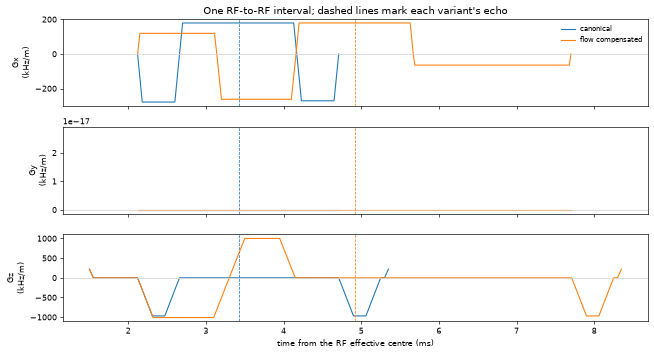

In [6]:
def waveform(kernel, line=CENTRE_LINE):
    """One RF-to-RF interval of `kernel`, as (time from the RF centre, Gx, Gy, Gz)."""
    scan = sc.LogicBlock()
    for index in range(3):
        scan.add(index * kernel.tr_s, kernel(line=line + index, phase_deg=180.0 * (index % 2)))
    seq = sc.compile(scan, opts)
    c = rf_centres(seq)
    out = []
    for axis in range(3):
        t, g = seq.waveforms_and_times()[0][axis]
        inside = (t >= c[0] - 0.4e-3) & (t <= c[1] + 0.1e-3)
        out.append((t[inside] - c[0], g[inside]))
    return out, c[1] - c[0], kernel.te_s


fig, axes = plt.subplots(3, 1, figsize=(11, 6.0), sharex=True)
for kernel, name, colour in ((canonical, 'canonical', 'C0'),
                             (compensated, 'flow compensated', 'C1')):
    curves, tr_s, te_s = waveform(kernel)
    for axis, (ax, label) in enumerate(zip(axes, ('Gx', 'Gy', 'Gz'))):
        t, g = curves[axis]
        ax.plot(t * 1e3, g / 1e3, lw=1.3, color=colour, label=name if axis == 0 else None)
        ax.set_ylabel(f'{label}\n(kHz/m)')
        ax.axhline(0.0, color='0.85', lw=0.8)
        ax.axvline(te_s * 1e3, color=colour, ls='--', lw=0.9)
axes[0].legend(frameon=False, fontsize=8, loc='upper right')
axes[0].set_title('One RF-to-RF interval; dashed lines mark each variant\'s echo')
axes[-1].set_xlabel('time from the RF effective centre (ms)')
fig.tight_layout()
plt.show()

Each single winder lobe has become a pair of opposite sign. A single lobe has only one degree of
freedom and can meet one condition; a bipolar pair has two, which is what lets the same waveform
place `k` where it belongs at the echo *and* arrive there with no first moment. The pair takes
longer than the lobe it replaces, and that time is the echo-time cost in the table above.

The slice axis shows the same change, and the leading winder before the pulse is unchanged: it
belongs to the previous repetition's balance and acts on magnetisation that does not exist yet,
so no moment condition at this echo touches it.

## 3. A moving spin

The moments say what should happen. A simulation says whether it does.

One voxel, moving at constant velocity along the readout axis, sampled at the centre of k-space.
The quantity is the echo phase relative to a stationary spin, and the prediction from §1 is

$$\Delta\phi = 2\pi\,v\,M_1 .$$

**The sign convention has to be established, not assumed.** A simulator reports phase under its
own convention, so before any velocity is read the same machinery is run on a *stationary* spin
displaced by a known offset under a known zeroth moment, where the answer is $2\pi x_0 M_0$ and
is known independently.

In [7]:
@contextlib.contextmanager
def quiet():
    """Silence the solver's log, which is written from Rust straight to file descriptor 1."""
    saved, null = _os.dup(1), _os.open(_os.devnull, _os.O_WRONLY)
    try:
        _os.dup2(null, 1)
        yield
    finally:
        _os.dup2(saved, 1)
        _os.close(null)
        _os.close(saved)


def write(kernel, name, *, line=CENTRE_LINE, reps=4):
    """
    A few repetitions at one line, every one acquired, as a NAV file.

    The measurement below reads the **first** repetition.  Its magnetisation was created at that
    repetition's own RF centre, so the phase it carries to the echo comes from that one interval
    and is the quantity the moments describe.  Later repetitions in a balanced train carry phase
    from every interval that came before, which is a different and more interesting quantity.
    """
    nav = pp.make_label(type='SET', label='NAV', value=1)
    out, at = sc.LogicBlock(name), 0.0
    for index in range(reps):
        out.add(at, kernel(line=line, phase_deg=180.0 * (index % 2)))
        out.add(at, nav)
        at += kernel.tr_s
    path = SEQ_DIR / f'{name}.seq'
    sc.compile(out, opts, name=name).write(str(path))
    return path


FILES = {'canonical': write(canonical, 'bssfp_flow_canonical'),
         'compensated': write(compensated, 'bssfp_flow_compensated')}


def moving_echo(path, kernel, v_m_s, axis='x', *, offset_m=0.0, sample=0):
    """
    One voxel's first-repetition signal, `sample` points after the echo.

    `sample` exists for the control below: away from the echo the readout has a known non-zero
    zeroth moment, which is what lets a displaced stationary spin establish the sign convention.
    """
    imported = mr0.Sequence.import_file(str(path))
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[1.0], T2=[0.2], T2dash=[1e3], D=[0.0],
        voxel_size=FOV_MM / NX / 1e3, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0
    built.B1 = built.B1.float() * 0.0 + 1.0
    base = built.voxel_pos.clone()
    base[:, 0] += offset_m
    index = 'xyz'.index(axis)

    def motion(t):
        step = torch.zeros((t.numel(), 1, 3), dtype=base.dtype)
        step[:, :, index] = v_m_s * t[:, None]
        return base[None, :, :] + step

    built.voxel_motion = motion
    with quiet():
        graph = mr0.compute_graph(imported, built, max_state_count=200, min_state_mag=1e-4)
        signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    rows = signal.reshape(-1, int(kernel.ro.adc.num_samples))
    return complex(rows[0, kernel.ro.echo_sample(0) + sample])

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/1391208834.py:30: SeqCraftWarning: 4 blocks over the vector-norm limit (legal on real amplifiers): bssfp_flow_canonical.bSSFP2DTR, bssfp_flow_canonical.bSSFP2DTR.CartesianLine, bssfp_flow_canonical.bSSFP2DTR.PhaseEncode (slew 135% at 4.260 ms), bssfp_flow_canonical.bSSFP2DTR, bssfp_flow_canonical.bSSFP2DTR.CartesianLine, bssfp_flow_canonical.bSSFP2DTR.PhaseEncode (slew 135% at 11.110 ms), bssfp_flow_canonical.bSSFP2DTR, bssfp_flow_canonical.bSSFP2DTR.CartesianLine, bssfp_flow_canonical.bSSFP2DTR.PhaseEncode (slew 135% at 17.960 ms), bssfp_flow_canonical.bSSFP2DTR, bssfp_flow_canonical.bSSFP2DTR.CartesianLine, bssfp_flow_canonical.bSSFP2DTR.PhaseEncode (slew 135% at 24.810 ms)
  sc.compile(out, opts, name=name).write(str(path))
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/1391208834.py:30: SeqCraftWarning: 8 same-axis gradient merges: bssfp_flow_compensated.bSSFP2DTR.joint (axis z) x4, bssfp_flow_compen

In [8]:
# ------------------------------------------------------------------ the static control
# A stationary voxel displaced along x, read SAMPLES points past the echo, where the readout has
# a known non-zero zeroth moment: k = SAMPLES / FOV.  The phase is then 2*pi*k*x0, known
# independently of anything measured here -- so this fixes both the scale and the sign that the
# velocity measurement below is read under.
SAMPLES = 8
k_per_m = SAMPLES / (FOV_MM / 1e3)


def control_phase(offset_mm):
    still = moving_echo(FILES['canonical'], canonical, 0.0, sample=SAMPLES)
    moved = moving_echo(FILES['canonical'], canonical, 0.0,
                        offset_m=offset_mm / 1e3, sample=SAMPLES)
    return float(np.angle(moved * np.conj(still)))


print(f'static control: stationary voxels displaced along x, read {SAMPLES} samples past the '
      f'echo\nwhere k = {k_per_m:.1f} 1/m\n')
print(f'{"offset / mm":>12}{"measured / pi":>15}{"2 pi k x0 / pi":>16}{"ratio":>9}')
ratios = []
for offset_mm in (-4.0, -2.0, 2.0, 4.0):
    measured_rad = control_phase(offset_mm)
    predicted_rad = 2 * np.pi * k_per_m * offset_mm / 1e3
    ratios.append(measured_rad / predicted_rad)
    print(f'{offset_mm:12.1f}{measured_rad / np.pi:15.4f}{predicted_rad / np.pi:16.4f}'
          f'{ratios[-1]:9.3f}')

SIGN = float(np.sign(np.mean(ratios)))
print(f'\nmean ratio {np.mean(ratios):+.3f}: this pipeline reports gradient phase with the '
      f'opposite sign\nto the 2 pi * moment convention used above, so the velocity phases below '
      f'carry a factor of {SIGN:+.0f}.')

static control: stationary voxels displaced along x, read 8 samples past the echo
where k = 32.0 1/m

 offset / mm  measured / pi  2 pi k x0 / pi    ratio
        -4.0         0.2560         -0.2560   -1.000


        -2.0         0.1280         -0.1280   -1.000


         2.0        -0.1280          0.1280   -1.000
         4.0        -0.2560          0.2560   -1.000

mean ratio -1.000: this pipeline reports gradient phase with the opposite sign
to the 2 pi * moment convention used above, so the velocity phases below carry a factor of -1.


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/754078289.py:32: SeqCraftWarning: 3 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 135% at 4.260 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 135% at 11.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 135% at 17.960 ms)
  seq = sc.compile(scan, opts)


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/754078289.py:32: SeqCraftWarning: 8 same-axis gradient merges: bSSFP2DTR.joint (axis z) x3, bSSFP2DTR.CartesianLine (axis x) x3, bSSFP2DTR.joint (axis y) x2
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_40725/754078289.py:32: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode, bSSFP2DTR.joint (grad 101% at 4.260 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode, bSSFP2DTR.joint (slew 129% at 4.260 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (grad 101% at 14.110 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (slew 129% at 14.110 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (grad 101% at 23.960 ms) (+1 more sites)
  seq = sc.compile(scan, opts)


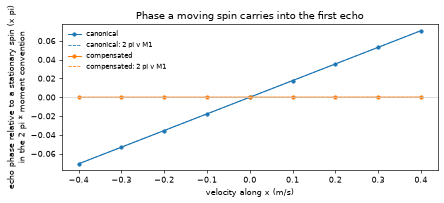

canonical    measured slope   +0.5557 rad/(m/s)   2 pi M1 =   +0.5562
compensated  measured slope   +0.0003 rad/(m/s)   2 pi M1 =   +0.0003


In [9]:
VELOCITIES = np.linspace(-0.4, 0.4, 9)      # m/s along the readout axis

measured, predicted = {}, {}
for name, kernel in (('canonical', canonical), ('compensated', compensated)):
    still = moving_echo(FILES[name], kernel, 0.0)
    phases = np.array([
        float(np.angle(moving_echo(FILES[name], kernel, v) * np.conj(still)))
        for v in VELOCITIES
    ])
    measured[name] = SIGN * np.unwrap(phases)
    m1_x = measure(kernel, [CENTRE_LINE, CENTRE_LINE + 1, CENTRE_LINE + 2])['m1_echo'][0]
    predicted[name] = 2 * np.pi * VELOCITIES * m1_x

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for name, colour in (('canonical', 'C0'), ('compensated', 'C1')):
    ax.plot(VELOCITIES, measured[name] / np.pi, 'o-', color=colour, lw=1.3, ms=4, label=name)
    ax.plot(VELOCITIES, predicted[name] / np.pi, '--', color=colour, lw=1.0,
            label=f'{name}: 2 pi v M1')
ax.axhline(0.0, color='0.8', lw=0.8)
ax.set_xlabel('velocity along x (m/s)')
ax.set_ylabel('echo phase relative to a stationary spin (x pi)\nin the 2 pi * moment convention')
ax.set_title('Phase a moving spin carries into the first echo')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

for name in measured:
    slope = np.polyfit(VELOCITIES, measured[name], 1)[0]
    m1_x = measure(canonical if name == 'canonical' else compensated,
                   [CENTRE_LINE, CENTRE_LINE + 1, CENTRE_LINE + 2])['m1_echo'][0]
    print(f'{name:12} measured slope {slope:+9.4f} rad/(m/s)   '
          f'2 pi M1 = {2 * np.pi * m1_x:+9.4f}')

The canonical sequence's phase rises with velocity along the line the first moment predicts. The
compensated one stays flat to within the residual §2 measured.

What that costs across a voxel: a voxel containing a spread of velocities contains a spread of
phase, and the vector sum of a spread of phases is smaller than the sum of aligned ones. That is
the signal loss flow compensation is bought to avoid, and it is why the dark rim at a vessel edge
— where the velocity spread across the voxel is largest — is the artefact that responds to it.

## Summary

- **Balanced is not motion compensated.** `M0 = 0` over the RF-to-RF interval is a statement
  about a stationary spin. A spin moving at constant velocity arrives at the echo with a phase
  $2\pi v M_1$, and the canonical repetition's $M_1$ is non-zero on all three axes.
- On the phase-encode axis $M_1$ is tied to the line, passing through zero at $k_y = 0$; on the
  readout and slice axes it is the same for every line.
- `flow_comp=sc.FlowCompensation(axis=...)` asks for $M_1 = 0$ at the echo as well. Measured, it
  falls by three to four orders of magnitude, the single winder lobes become bipolar pairs, and
  TE and TR grow by about 45 % on this protocol.
- **The balance condition is unaffected.** The two requirements live on different intervals: the
  design reshapes what plays between the RF centre and the echo and leaves the total area on each
  axis alone, so the RF-to-RF sum is the one the canonical repetition had.
- A moving spin simulated against both variants follows the predicted phase in the canonical
  sequence and stays flat in the compensated one.

### What this notebook does not establish

- That flow compensation is worth its cost for a given protocol. It costs echo time, and in bSSFP
  a longer TR moves the off-resonance band spacing — `02` measures that spacing, and the trade
  between the two is a protocol decision this notebook does not make.
- Anything about acceleration or higher-order motion. Only the first moment is nulled, so a spin
  that is accelerating still accrues phase from the moments above it.
- Anything about an object. The measurements here are single voxels with a single velocity each;
  an image of a vessel contains a distribution of velocities within every voxel and across them,
  and nothing here simulates that.
- Anything about a real scanner. MRzero applies each pulse as a rotation by its integrated
  envelope, and the motion model is a voxel translated at constant velocity.

## References

1. Bernstein MA, King KF, Zhou XJ. *Handbook of MRI Pulse Sequences.* Elsevier, 2004, §9.2 —
   gradient moment nulling — and §14.1 for the balanced SSFP family.
2. Pattany PM, Phillips JJ, Chiu LC, et al. *Motion artifact suppression technique (MAST) for MR
   imaging.* J Comput Assist Tomogr 1987;11:369.
3. Bieri O, Scheffler K. *Flow compensation in balanced SSFP sequences.* Magn Reson Med
   2005;54:901.
4. Markl M, Frydrychowicz A, Kozerke S, Hope M, Wieben O. *4D flow MRI.* J Magn Reson Imaging
   2012;36:1015.